# Monte Carlo simulation of the 2D Ising model

**Question:** How does the mean absolute magnetization change with temperature?

This notebook accompanies the [10-minute project presentation](https://docs.google.com/presentation/d/1KAFb_y9PtoIpSW4TPFgb8FJGoKyu-NY-hI6zPfiZNhQ/edit).
It starts with one spin array, checks a spin flip, and then reproduces the presentation's results from the saved course data.
The first seven sections develop the main analysis. Section 8 compares sizes and Binder crossings; section 10 sets out the response-function and spatial-visualization extensions.

**Run:** Extract the full package, open this notebook, and select **Restart Kernel and Run All**.
The default run reuses the saved production scan. It does not regenerate the full temperature scan.
The complete simulation functions are in `ising_kernel.py`; the plotting and validation functions are in `project.py`.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import project as p
import ising_kernel as ising

p.configure_plotting()
print("Working folder:", Path.cwd().name)
print("Saved scan found:", p.DATA.is_file())

Working folder: ising-project-example
Saved scan found: True


## 1. Start with one spin configuration

Each entry is one spin, $s_{ij}=+1$ or $-1$. The lattice has $N=L^2$ spins.
White means $+1$ and black means $-1$ in the pictures below.

The magnetization per spin is $m=N^{-1}\sum_i s_i$.
Its sign identifies the majority direction; its absolute value measures the imbalance in spin counts.
An all-up array and an all-down array both have $|m|=1$.
A zero moment alone does not determine the spatial arrangement of spins.

In [2]:
spins = np.array([[1, 1, 1, 1],
                  [1, 1, 1, 1],
                  [1, 1, -1, -1],
                  [-1, -1, -1, -1]])
N = spins.size
print(spins)
print("Number of spins:", N)
print("Magnetization per spin:", spins.sum() / N)
print("Instantaneous absolute magnetization:", abs(spins.mean()))

[[ 1  1  1  1]
 [ 1  1  1  1]
 [ 1  1 -1 -1]
 [-1 -1 -1 -1]]
Number of spins: 16
Magnetization per spin: 0.25
Instantaneous absolute magnetization: 0.25


## 2. Energy and one proposed flip

The zero-field ferromagnetic model has energy

$$E=-J\sum_{\langle ij\rangle}s_i s_j,\qquad J>0.$$

Count each nearest-neighbor bond once. Periodic boundaries join opposite edges.
The code uses $J=k_{\mathrm B}=1$, so its temperature `T` is the reduced temperature $k_{\mathrm B}T/J$.
For a flip at one site, $\Delta E=2J s_i\sum_{j\in\mathrm{neighbors}(i)}s_j$.

A spin aligned with all four neighbors costs $8J$ to flip.
Metropolis accepts a proposal with probability $\min(1,\exp[-\Delta E/(k_{\mathrm B}T)])$.
When a proposal is rejected, keep the old array. One sweep means $N$ attempted flips with randomly selected sites.

In [3]:
aligned = np.ones((4, 4), dtype=np.int64)
trial = aligned.copy()
trial[1, 1] *= -1
local_change = ising.delta_energy(aligned, 1, 1)
full_change = ising.total_energy(trial) - ising.total_energy(aligned)
print("Aligned energy:", ising.total_energy(aligned))
print("Local and full energy change:", local_change, full_change)
for T in [1.5, 3.5]:
    probability = min(1.0, np.exp(-local_change / T))
    accepted_state = aligned.copy()
    accepted = ising.flip_local(accepted_state, T, 1, 1, u=0.05)
    print(f"T = {T:.1f}: acceptance probability = {probability:.5f}, accepted with u=0.05: {accepted}")

Aligned energy: -32
Local and full energy change: 8 8
T = 1.5: acceptance probability = 0.00483, accepted with u=0.05: False
T = 3.5: acceptance probability = 0.10170, accepted with u=0.05: True


Check the actual implementation against an independent full bond sum for all 512 arrays of a 3-by-3 lattice.
This tests 4,608 energy changes and 41,472 controlled acceptance decisions.
It validates the update rule, not equilibration of a long simulation.

{'states': 512, 'spin_flips': 4608, 'acceptance_checks': 41472}


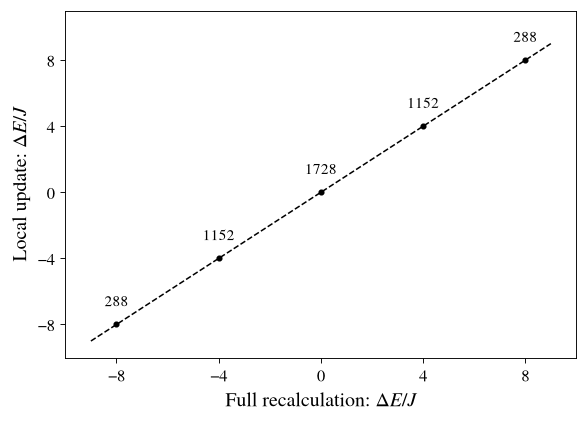

In [4]:
kernel_check = p.verify_kernel()
print({key: value for key, value in kernel_check.items() if key != "delta_energy_counts"})
p.plot_energy_check(kernel_check)
plt.show()

*Energy-change check.* Labels count overlapping comparisons at each possible energy change.
All comparisons lie on the diagonal.

## 3. Follow the same initial array at two temperatures

Reproduce the original 12-by-12 demonstration: seed 42 and 500 sweeps at each temperature.
Both calculations start from the same random array. The replay must match the saved demonstration exactly.
These short trajectories illustrate the dynamics; they are not the production averages used later.

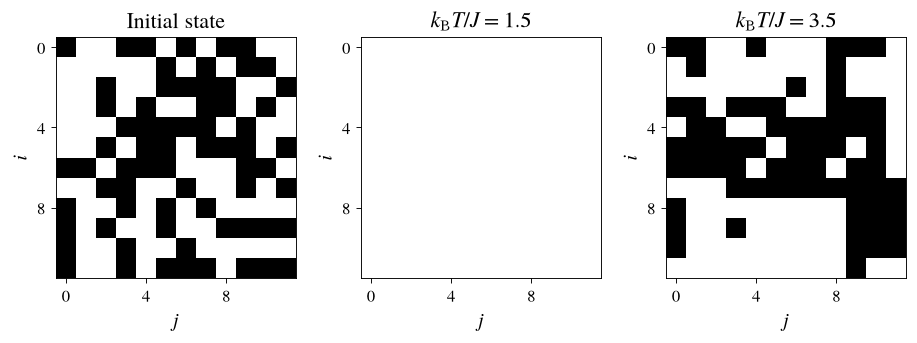

T = 1.5: final instantaneous |m| = 1.0000
T = 3.5: final instantaneous |m| = 0.0694


In [5]:
initial, final_states, short_traces = p.replay_illustration()
p.plot_states(initial, final_states)
plt.show()
for T, state in zip([1.5, 3.5], final_states):
    print(f"T = {T:.1f}: final instantaneous |m| = {abs(state.mean()):.4f}")

*Spin configurations.* The two final snapshots follow 500 sweeps from the common initial state.
At low temperature the final array is nearly aligned. At high temperature both directions remain mixed.

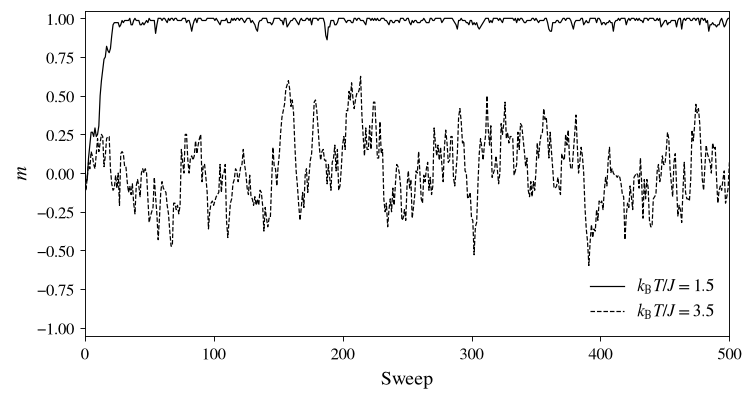

In [6]:
p.plot_traces(short_traces)
plt.show()

*Short magnetization trajectories.* Opposite signs represent opposite majority directions.
A trajectory remaining at one sign does not prove a preferred direction in the exact finite-system equilibrium distribution.

## 4. Load the production measurements

The original scan uses sizes 8, 16, and 32 at 12 temperatures from 1.5 to 3.5.
At each temperature and size it uses four separate random streams, alternating aligned and random starts.
Each run discards 8,000 sweeps, then records 16,000 measurements separated by five sweeps.
Spacing measurements does not guarantee that they are independent.

The sample axes are **size, temperature, run, observable, measurement**.
Observable index 0 is total energy in units of the coupling; index 1 is total magnetization.

Sizes: [ 8 16 32]
Temperatures: [1.5  2.   2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.5  3.   3.5 ]
Runs, discarded sweeps, samples, stride: [    4  8000 16000     5]
Sample array shape: (3, 12, 4, 2, 16000)


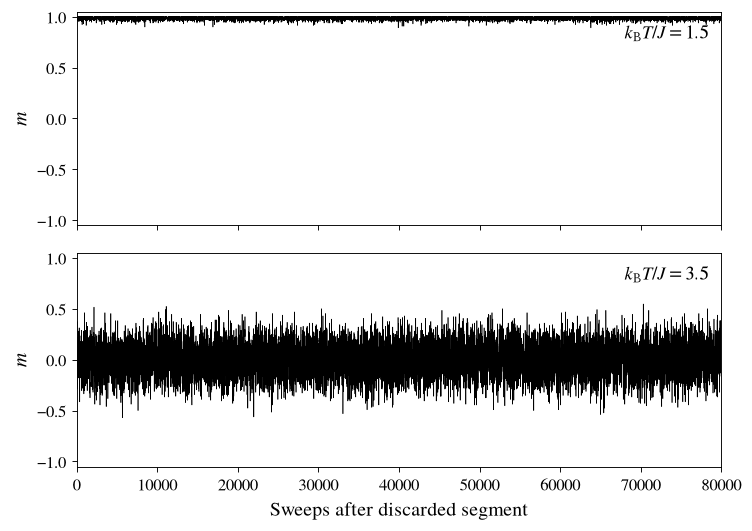

In [7]:
scan = p.load_scan()
print("Sizes:", scan["sizes"])
print("Temperatures:", scan["temperatures"])
print("Runs, discarded sweeps, samples, stride:", scan["parameters"])
print("Sample array shape:", scan["samples"].shape)
p.plot_production(scan)
plt.show()

*Production magnetization.* One size-16 run at each of two temperatures, shown only after the discarded segment.
The short demonstration above and these production streams are separate calculations.

## 5. Measure the temperature dependence

First compute $\langle |m|\rangle_r$ separately within each run $r$.
Then average the four run estimates:

$$\bar x=\frac{1}{R}\sum_{r=1}^{R}x_r,\qquad
\mathrm{SE}(\bar x)=\frac{s_x}{\sqrt{R}},\qquad R=4.$$

Here $s_x$ is the sample standard deviation of the run estimates, using `ddof=1`.
Do not count every correlated measurement as a separate independent run.
The error bars represent sampling variability between the four runs and exclude finite-size and equilibration bias.

{'data_sha256': '082bb7a6329a1ed3afb902447a41786425555507ade237cc5e59a9d4bfaf3094', 'mean_and_se_match': True, 'max_mean_difference': 0.0, 'max_se_difference': 0.0}


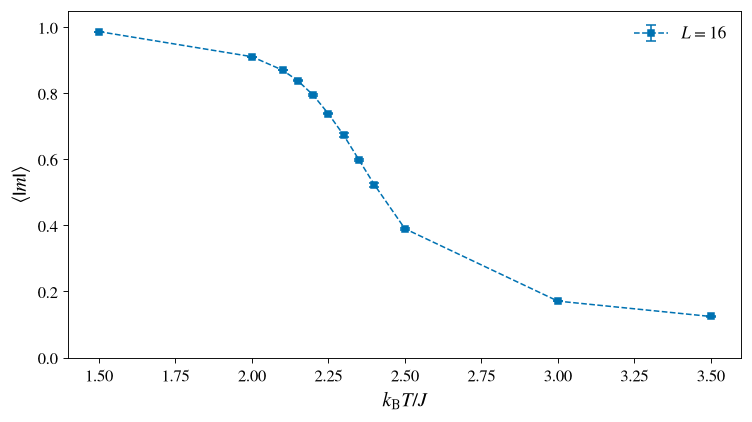

T = 1.5: mean |m| = 0.986510, SE = 0.000049
T = 3.5: mean |m| = 0.124244, SE = 0.000321


In [8]:
values, mean, se = p.reduce_scan(scan)
print(p.verify_reduction(scan, mean, se))
p.plot_magnetization(scan, mean, se)
plt.show()
for b in [0, -1]:
    print(f"T = {scan['temperatures'][b]:.1f}: mean |m| = {mean[1, b, 1]:.6f}, SE = {se[1, b, 1]:.6f}")

*Main result.* Size-16 mean absolute magnetization decreases on heating.
Points average four run estimates; error bars show one standard error across runs.
Lines connect sampled temperatures and are not fitted curves.

### Check against exact enumeration

On a 3-by-3 periodic lattice, enumerate all 512 configurations and weight them by their Boltzmann probabilities.
Compare the same mean absolute magnetization with eight independent Monte Carlo runs.
The benchmark uses 1,000 discarded sweeps, 16,000 measurements, stride 3, and seeds 200–207.
These are benchmark settings, separate from the size-16 production scan.
This checks small-lattice results; it does not establish convergence at larger sizes.

In [9]:
benchmark = p.exact_benchmark()
print('Temperature    Exact mean    MC mean    MC standard error')
for item in benchmark['comparisons']:
    print(f"{item['T']:8.1f}       {item['exact'][1]:.5f}       {item['mean'][1]:.5f}    {item['se'][1]:.5f}")
print('Matches retained benchmark:', benchmark['matches_retained_benchmark'])

Temperature    Exact mean    MC mean    MC standard error
     1.5       0.98534       0.98538    0.00027
     2.3       0.86408       0.86373    0.00099
     3.5       0.60879       0.60868    0.00087
Matches retained benchmark: True


## 6. See where an error bar comes from

At temperature 2.30, plot the four run means before averaging them.
The band is one standard error of their mean. Four runs provide a limited estimate of sampling variability.

Four independent run means: [0.68004492 0.67005469 0.68324805 0.65816846]
Mean: 0.6728790283203125
Standard error: 0.00565128587833805


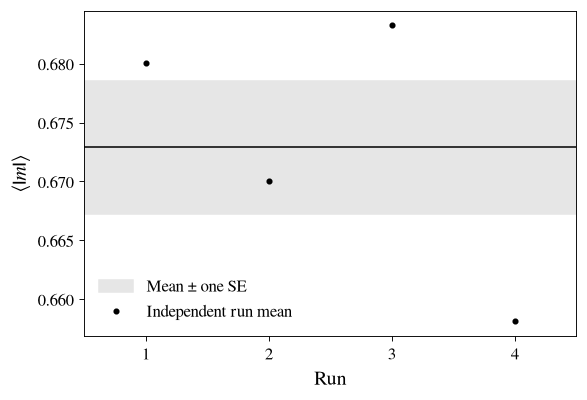

In [10]:
run_means = values[1, 6, :, 1]
print("Four independent run means:", run_means)
print("Mean:", run_means.mean())
print("Standard error:", run_means.std(ddof=1) / np.sqrt(len(run_means)))
p.plot_run_means(values)
plt.show()

*Run-to-run variation.* One point represents one complete run at $L=16$ and $k_{\mathrm B}T/J=2.30$.
The band is not a confidence interval and does not test equilibration bias.

## 7. State the result and its limits

The size-16 calculation shows a decrease in mean absolute magnetization between reduced temperatures 1.5 and 3.5.
This agrees with the change in spin configurations on heating.
The local energy update passes the independent enumeration check.

A finite high-temperature array can still have unequal spin counts, so a positive $\langle|m|\rangle$ alone does not establish order.
The exact signed average is zero at finite size and zero field, although a short low-temperature run may rarely change sign.
The existing evidence does not determine a precise infinite-system transition temperature.

For the presentation: explain the question, model, update rule, check, main result, error bars, and remaining tests.
The slide notes provide 600 seconds of suggested speaking time, ending with response functions and spatial spin correlations.

## 8. Backup analysis: size dependence and Binder crossings

Use the same retained scan to compare lattice sizes.
Larger lattices show a sharper drop and a smaller residual absolute magnetization at high temperature.

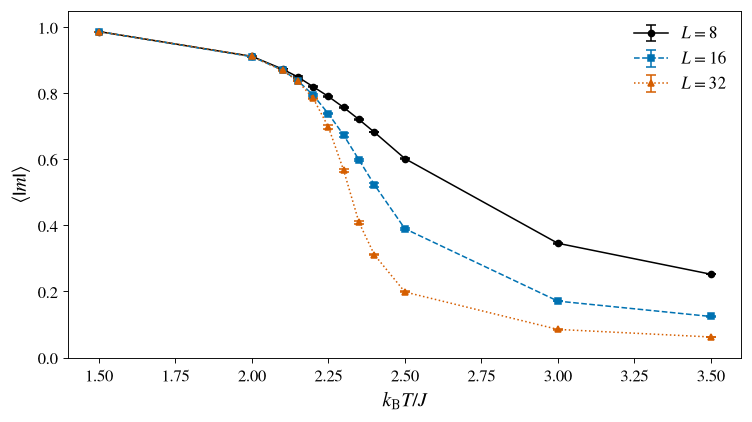

In [11]:
p.plot_magnetization(scan, mean, se, all_sizes=True)
plt.show()

*Size dependence.* The temperatures, boundary conditions, and sampling parameters are the same for all sizes.
Error bars are the standard errors across four runs at each point.

The Binder cumulant summarizes the signed magnetization distribution through its even moments:

$$U_4=1-\frac{\langle m^4\rangle}{3\langle m^2\rangle^2}.$$

To reproduce the existing slides, compute this ratio separately for each run, then average the four estimates.
A ratio computed after pooling all runs is a different finite-sample estimator.
Linear interpolation locates crossings within the sampled temperature grid.

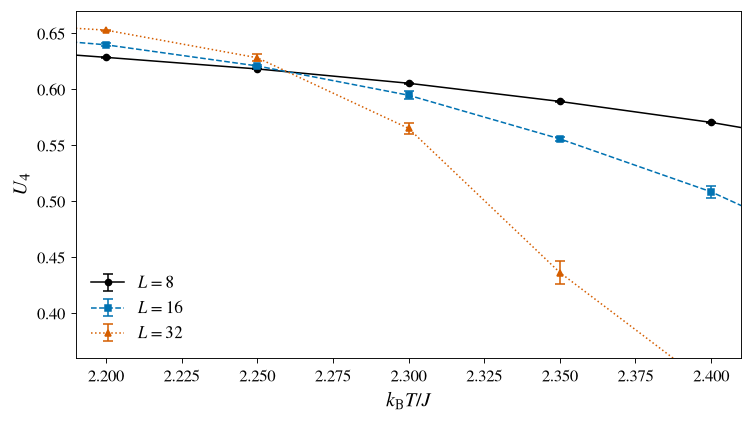

Sizes 8 and 16: crossing near 2.26; sampled bracket 2.25–2.30
Sizes 16 and 32: crossing near 2.26; sampled bracket 2.25–2.30


In [12]:
p.plot_binder(scan, mean, se)
plt.show()
for a in range(2):
    roots = ising.crossings(scan["temperatures"], mean[a, :, 3] - mean[a + 1, :, 3])
    for left, right, root in roots:
        print(f"Sizes {scan['sizes'][a]} and {scan['sizes'][a+1]}: crossing near {root:.2f}; sampled bracket {left:.2f}–{right:.2f}")

*Binder crossings.* Both neighboring size pairs cross near 2.26 within the sampled bracket 2.25–2.30.
The bracket is a grid interval, not a confidence interval.
A finer temperature grid, more runs, and checks of starting state and discarded length are needed for a precise estimate.
Those extensions are not claimed as completed in this worked example.

## 9. Save the results and optionally replay a production stream

The default export writes the recalculated observables and crossing estimates to `results/`.
For a stronger reproducibility check, set `REPLAY_PRODUCTION = True` below.
This reruns one saved size-8 stream, including its random initial state and discarded sweeps, and compares every recorded energy and magnetization.
It checks reproducibility of that stream, not convergence of the whole scan.

In [13]:
report = p.export_results(scan, values, mean, se, Path("results"))
print("Saved results/observables.csv and results/results.json")
REPLAY_PRODUCTION = False
if REPLAY_PRODUCTION:
    print(p.production_replay(scan))

Saved results/observables.csv and results/results.json


## 10. Next: response functions and spin patterns

The next analysis goes beyond the mean magnetization.

**Heat capacity.** At fixed field, the heat capacity per spin follows from energy fluctuations:

$$c=\frac{1}{N}\left(\frac{\partial\langle E\rangle}{\partial T}\right)_h
=\frac{\langle E^2\rangle-\langle E\rangle^2}{Nk_{\mathrm B}T^2}.$$

The current code already calculates this quantity. Compare its peak across lattice sizes, refine the temperature grid, and repeat with longer runs.

**Susceptibility.** Add a model field through $E(h)=E(0)-hM$ and compare the magnetization at small positive and negative fields:

$$\chi=\left(\frac{\partial\langle m\rangle}{\partial h}\right)_T
=\frac{N}{k_{\mathrm B}T}\left(\langle m^2\rangle-\langle m\rangle^2\right).$$

Here $h$ has energy units and $m=M/N$ is signed magnetization. The variance of $|m|$ is a different quantity.
Reduce the field step to check the linear-response range. Sampling must include both magnetization directions when estimating the finite-system zero-field equilibrium response.
These formulas use physical temperature; the course code sets $J=k_{\mathrm B}=1$.

**Spin patterns.** Two arrays can have the same net magnetization and different domains.
Record spin configurations near the transition, animate them in Monte Carlo sweep order, and calculate the spatial pair correlation

$$G(\mathbf r)=\frac{1}{N}\sum_i\langle s_i s_{i+\mathbf r}\rangle.$$

Average over lattice sites and equilibrated samples. The movie shows Monte Carlo updates, not a calibrated time evolution of a real magnet.
The weak-field comparison and spatial-correlation study are proposed extensions, not new results in this package.


## Sources and reproducibility

The production data and simulation kernel are unchanged copies of the original course files.
The illustration uses the Ising I seed and random-number draw order; the analysis follows Ising II.
`manifest.json` records file hashes and original paths.
The existing slide deck contains the 10-minute main talk and seven backup slides; its Korean speaker notes are included.

To regenerate the saved figure files without Jupyter, run `python project.py` in this directory.
SVG files retain vector lines and labels; PNG files are provided for convenient insertion into slides.

**AI assistance:** OpenAI Codex assisted with this notebook, analysis and figure code, the presentation structure and wording,
and automated checks. The saved production data and original course kernel were reused unchanged.
The README records the sources, changes, verification, and presentation timing.